In [1]:
# Music staff paper — three densities (regular / extra / super).
# Each staff is 5 horizontal lines spaced U pixels (top-of-line to top-of-line).
# Staves stacked vertically with G empty pixel rows between adjacent staves.
#
# CONSTRAINT (preserves exact 120 px top/bottom margins):
#   N · (4U + ELEM_SIZE) + (N−1) · G = USABLE_H = 10510
# where N = staves per page, U = within-staff line spacing, G = inter-staff gap.
# For the chosen N, U is restricted so G comes out integer:
#   N=6:  U ≡ 0 (mod 5)
#   N=10: U ≡ 6 (mod 9)
#   N=15: U ≡ 0 (mod 7)
#
# Output: ../output/music/{music,extra-music,super-music}.png
from PIL import Image
from IPython.display import display
from common import (
    blank_page, draw_header, hline, ELEM_SIZE,
    HEIGHT, MARGIN, HEADER_HEIGHT,
    output_path, variant_name,
)

MODE = "music"
USABLE_H = HEIGHT - HEADER_HEIGHT - 2 * MARGIN   # 10510

# (N, U, G) per density. Each tuple satisfies N*(4U+10) + (N-1)*G == 10510.
STAVES = {
    "regular": (6,  150, 1370),   # 6 staves,  staff h=610, gap 1370
    "extra":   (10, 105, 690),    # 10 staves, staff h=430, gap 690
    "super":   (15, 70,  440),    # 15 staves, staff h=290, gap 440
}

In [2]:
def render_music(n_staves, U, G):
    staff_h = 4 * U + ELEM_SIZE
    assert n_staves * staff_h + (n_staves - 1) * G == USABLE_H, \
        "(N, U, G) doesn't sum to USABLE_H"
    img = blank_page()
    for k in range(n_staves):
        staff_top = HEADER_HEIGHT + MARGIN + k * (staff_h + G)
        for line in range(5):
            hline(img, staff_top + line * U)
    draw_header(img)
    return img, staff_h

regular  N= 6  U=150  G=1370  staff_h=610  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/music/music.png


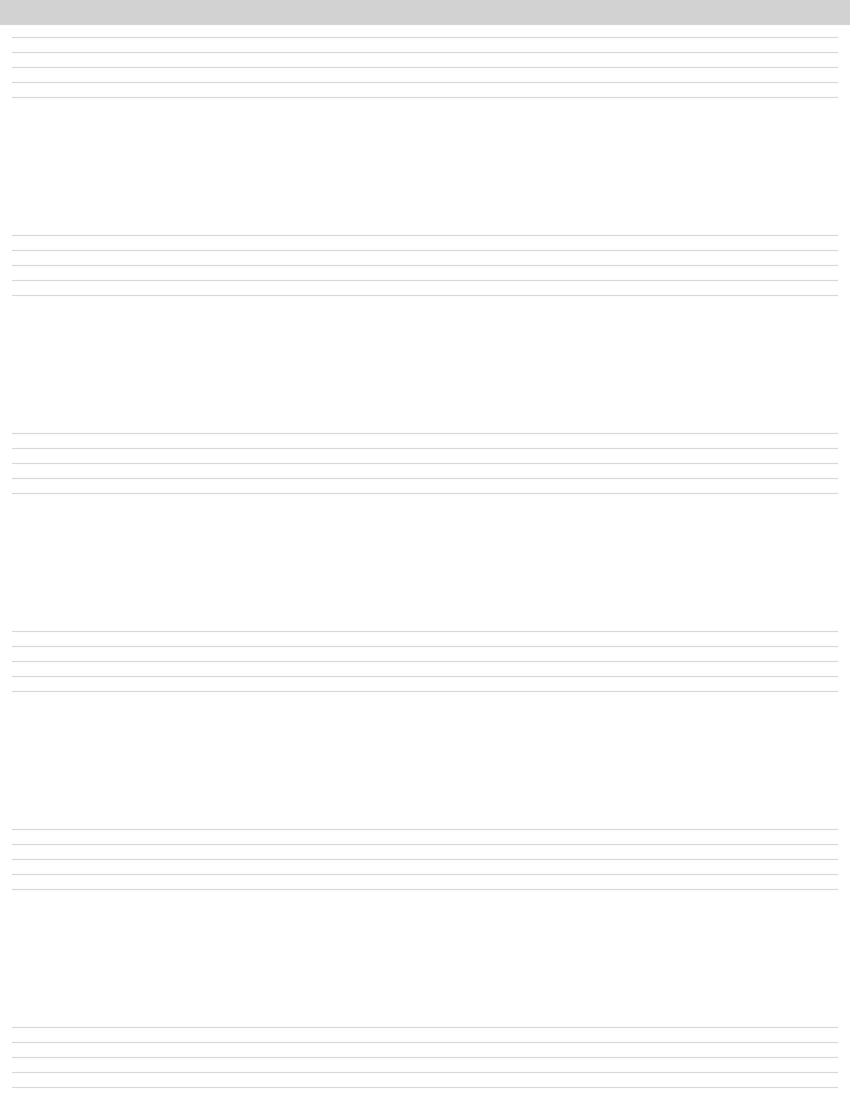

extra    N=10  U=105  G= 690  staff_h=430  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/music/extra-music.png


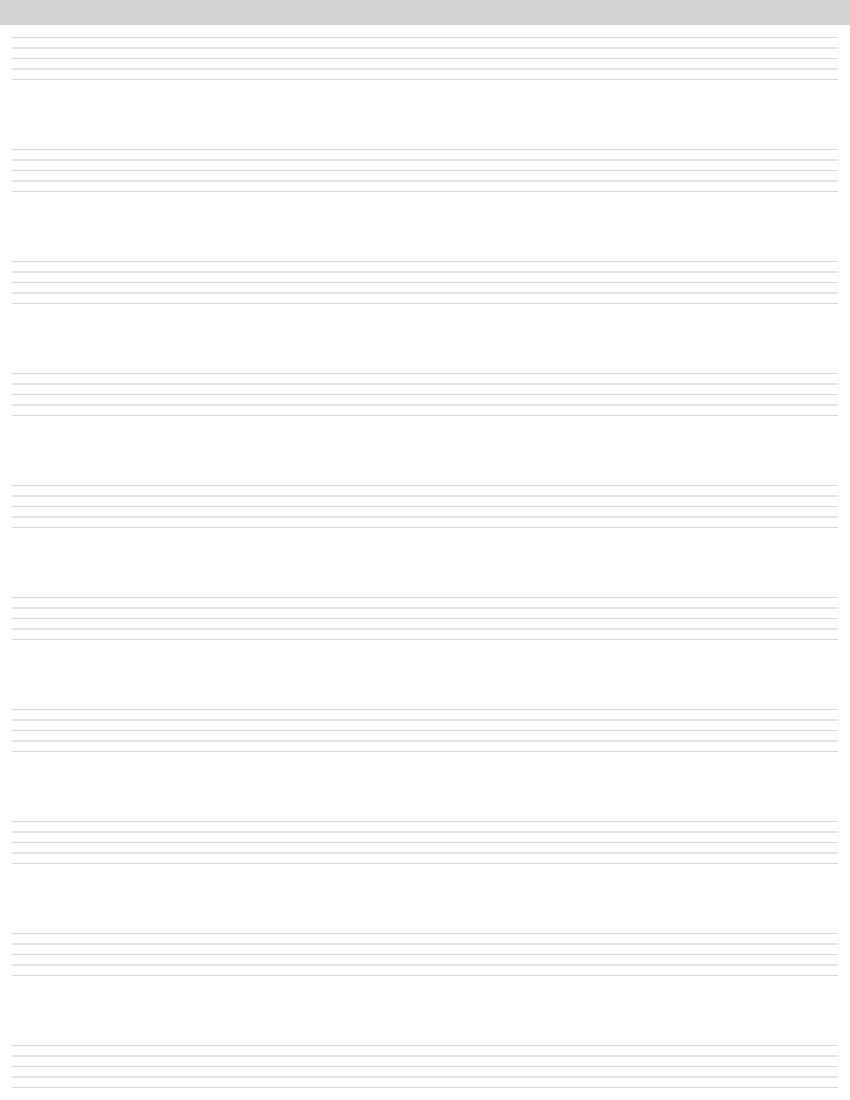

super    N=15  U= 70  G= 440  staff_h=290  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/music/super-music.png


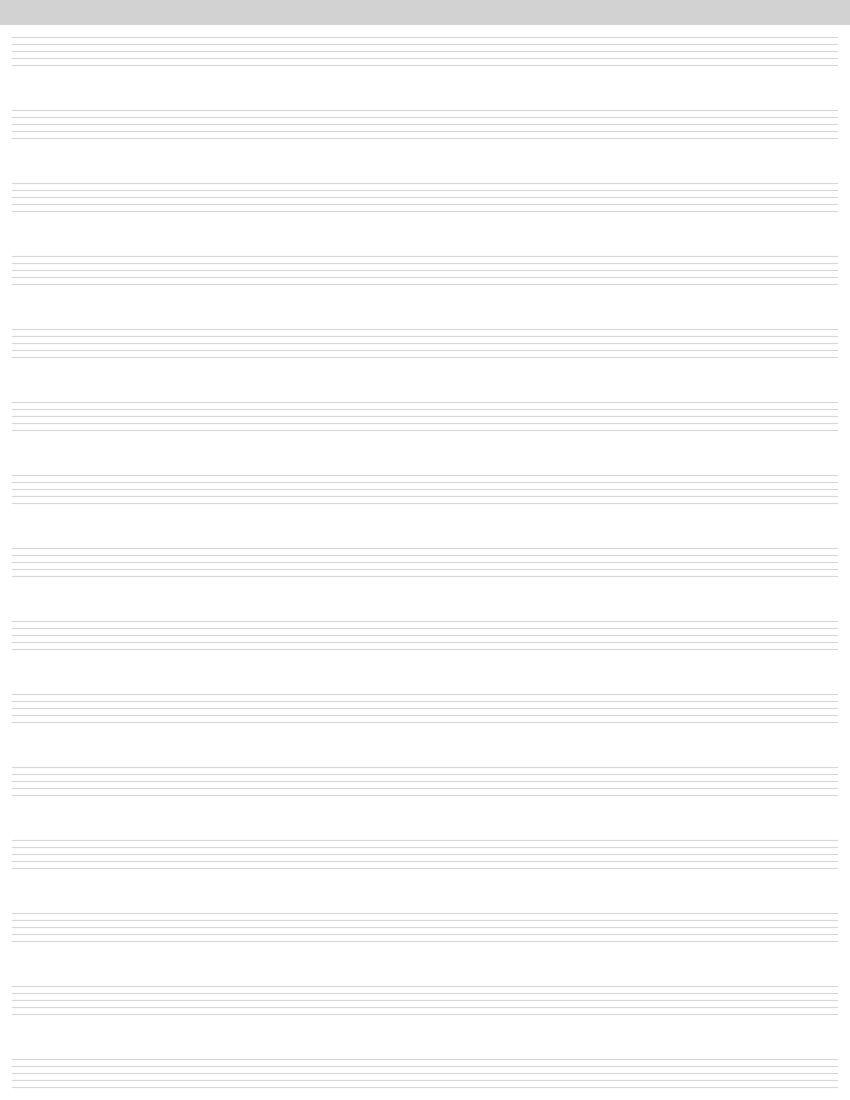

In [3]:
for density, (N, U, G) in STAVES.items():
    img, staff_h = render_music(N, U, G)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} N={N:2d}  U={U:3d}  G={G:4d}  "
        f"staff_h={staff_h}  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))